# Direct Transfer Summary Table

This notebook reads the copied transition logs from `logs/sim2real_transitions/presslight` and summarizes the available comparison methods:

- `direct_transfer` for each network and setting
- `domain_randomization` for each network and setting
- `domain_adaptation` for each network and setting
- `gat` for each network and setting
- `ugat` for each network and setting
- `jlgat` for each network and setting

Method-specific metric rules:

- `direct_transfer`: `FINAL_TEST` travel time from the latest copied SUMO direct-transfer DTL log
- `domain_randomization`: take the top `TOP_REWARD_K` real/equivalent rows by reward from `TEST_REAL` or `TRAIN_REAL` rows in the newest available DR DTL log, then average their metrics
- `domain_adaptation`: take the top `TOP_REWARD_K` real/equivalent rows by reward from `REAL_EVAL` or `REAL_EVAL_FINAL` rows in the newest available DA DTL log, then average their metrics
- `gat`, `ugat`, `jlgat`: take the top `TOP_REWARD_K` `Real rollout` rows by reward in the copied DTL log for that network and setting, then average their metrics

`cityflow_direct_transfer` is still loaded internally as the baseline used to compute gaps, but it is not shown as a comparison method in the gap table or plots. The gap chart remains ATT-based: it plots the selected rows' average travel time minus the cityflow direct-transfer travel time.


In [1]:
from pathlib import Path
import re
import numpy as np

import pandas as pd

LOG_ROOT = Path("logs/sim2real_transitions/presslight")
TOP_REWARD_K = 5

NETWORK_ORDER = [
    "tempe_1x1",
    "bullhead_1",
    "cologne1",
    "ingolstadt1",
    "hz1x1",
    "tempe_16",
    "bullhead_3",
    "cologne3",
    "ingolstadt7",
    "hz4x4",
]

SETTING_ORDER = ["setting1", "setting2", "setting3", "setting4"]
METHOD_ORDER = [
    "direct_transfer",
    "domain_randomization",
    "domain_adaptation",
    "gat",
    "ugat",
    "jlgat",
]

COLUMNS = [
    "exp_name",
    "mode",
    "episode",
    "travel_time",
    "aux",
    "reward",
    "queue",
    "delay",
    "throughput",
]

METRIC_COLUMNS = ["travel_time", "aux", "reward", "queue", "delay", "throughput"]
NUMERIC_COLUMNS = ["episode", *METRIC_COLUMNS]

TEXT_REAL_ROLLOUT_RE = re.compile(r"^Real rollout step:(?P<episode>\d+)/\d+, travel time:(?P<travel_time>-?\d+(?:\.\d+)?)")


In [2]:
# NETWORK_ORDER = ["bullhead_3"]
# SETTING_ORDER = ["setting2"]


In [3]:
def read_tabular_dtl(log_path: Path):
    df = pd.read_csv(log_path, sep="	", header=None, names=COLUMNS)
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def empty_metric_result(log_file=pd.NA):
    result = {column: pd.NA for column in METRIC_COLUMNS}
    for column in METRIC_COLUMNS:
        result[f"{column}_std"] = pd.NA
    result.update(
        {
            "episode": pd.NA,
            "selected_episodes": pd.NA,
            "selection_count": 0,
            "log_file": log_file,
        }
    )
    return result


def metric_result_from_row(row, log_path: Path | None = None):
    result = {}
    for column in METRIC_COLUMNS:
        value = pd.to_numeric(row[column], errors="coerce")
        result[column] = float(value) if pd.notna(value) else pd.NA
        result[f"{column}_std"] = pd.NA

    episode = pd.to_numeric(row["episode"], errors="coerce")
    episode = int(episode) if pd.notna(episode) else pd.NA

    result.update(
        {
            "episode": episode,
            "selected_episodes": str(episode) if pd.notna(episode) else pd.NA,
            "selection_count": 1,
            "log_file": log_path.name if log_path is not None else pd.NA,
        }
    )
    return result


def metric_result_from_top_reward_rows(rows, log_path: Path, top_k: int = TOP_REWARD_K):
    selected_df = rows.sort_values("reward", ascending=False).head(top_k).copy()
    if selected_df.empty:
        return empty_metric_result(log_path.name)

    result = {}
    for column in METRIC_COLUMNS:
        values = selected_df[column].dropna()
        result[column] = float(values.mean()) if not values.empty else pd.NA
        result[f"{column}_std"] = float(values.std(ddof=1)) if len(values) > 1 else pd.NA

    episodes = selected_df["episode"].dropna()
    selected_episodes = ", ".join(str(int(episode)) for episode in episodes)
    result.update(
        {
            "episode": float(episodes.mean()) if not episodes.empty else pd.NA,
            "selected_episodes": selected_episodes if selected_episodes else pd.NA,
            "selection_count": int(len(selected_df)),
            "log_file": log_path.name,
        }
    )
    return result


def read_top_reward_average_dtl_modes(log_path: Path, modes, top_k: int = TOP_REWARD_K):
    df = read_tabular_dtl(log_path)
    mode_df = df[df["mode"].isin(modes)].copy()
    mode_df = mode_df[mode_df["travel_time"].notna() & mode_df["reward"].notna()]
    if mode_df.empty:
        return empty_metric_result(log_path.name)

    return metric_result_from_top_reward_rows(mode_df, log_path, top_k=top_k)


def read_latest_top_reward_average_result(candidate_dirs, modes, top_k: int = TOP_REWARD_K):
    log_files = []
    for log_dir in candidate_dirs:
        log_files.extend(log_dir.glob("*_DTL.log"))

    for log_path in sorted(log_files, key=lambda path: (path.name, str(path)), reverse=True):
        result = read_top_reward_average_dtl_modes(log_path, modes, top_k=top_k)
        if pd.notna(result["travel_time"]):
            return result

    return empty_metric_result()


def read_direct_transfer_final_test(log_path: Path):
    df = read_tabular_dtl(log_path)
    final_df = df[df["mode"] == "FINAL_TEST"].copy()
    if final_df.empty:
        return empty_metric_result(log_path.name)
    return metric_result_from_row(final_df.iloc[-1], log_path)


def read_domain_randomization_result(network: str, setting: str):
    candidate_dirs = [
        LOG_ROOT / network / "domain_randomization_eval" / setting,
        LOG_ROOT / network / "domain_randomization" / setting,
    ]
    return read_latest_top_reward_average_result(candidate_dirs, ["TEST_REAL", "TRAIN_REAL"])


def read_domain_adaptation_result(network: str, setting: str):
    candidate_dirs = [LOG_ROOT / network / "domain_adaptation" / setting]
    return read_latest_top_reward_average_result(candidate_dirs, ["REAL_EVAL", "REAL_EVAL_FINAL"])


def read_top_reward_average_real_rollout(log_path: Path):
    text = log_path.read_text().strip()
    if not text:
        return empty_metric_result(log_path.name)

    first_line = text.splitlines()[0]
    if "	" in first_line:
        return read_top_reward_average_dtl_modes(log_path, ["Real rollout"])

    # Legacy text rollout logs do not include reward or full metrics, so keep a lowest-ATT fallback.
    best = None
    best_episode = pd.NA

    for line in text.splitlines():
        match = TEXT_REAL_ROLLOUT_RE.match(line.strip())
        if match:
            value = float(match.group("travel_time"))
            if best is None or value < best:
                best = value
                best_episode = int(match.group("episode"))

    if best is None:
        return empty_metric_result(log_path.name)

    result = empty_metric_result(log_path.name)
    result.update(
        {
            "travel_time": float(best),
            "episode": best_episode,
            "selected_episodes": str(best_episode) if pd.notna(best_episode) else pd.NA,
            "selection_count": 1,
        }
    )
    return result


def store_method_result(row, method: str, result):
    row[method] = result["travel_time"]
    for column in METRIC_COLUMNS:
        row[f"{method}_{column}"] = result[column]
        row[f"{method}_{column}_std"] = result.get(f"{column}_std", pd.NA)
    row[f"{method}_episode"] = result["episode"]
    row[f"{method}_selected_episodes"] = result["selected_episodes"]
    row[f"{method}_selection_count"] = result["selection_count"]
    row[f"{method}_log_file"] = result["log_file"]


def format_method_cell(value, selection_count, throughput):
    if pd.isna(value):
        return pd.NA
    parts = []
    if pd.notna(selection_count) and int(selection_count) > 1:
        parts.append(f"n {int(selection_count)}")
    if pd.notna(throughput):
        parts.append(f"tp {int(throughput)}" if float(throughput).is_integer() else f"tp {throughput:.1f}")
    details = ", ".join(parts)
    return f"{value:.1f} ({details})" if details else f"{value:.1f}"


method_rows = []
for network in NETWORK_ORDER:
    cityflow_log_files = sorted((LOG_ROOT / network / "cityflow_direct_transfer").glob("*_DTL.log"))
    cityflow_result = read_direct_transfer_final_test(cityflow_log_files[-1]) if cityflow_log_files else empty_metric_result()

    for setting in SETTING_ORDER:
        row = {
            "network": network,
            "setting": setting,
        }
        store_method_result(row, "cityflow_direct_transfer", cityflow_result)

        sumo_log_files = sorted((LOG_ROOT / network / "sumo_direct_transfer" / setting).glob("*_DTL.log"))
        direct_result = read_direct_transfer_final_test(sumo_log_files[-1]) if sumo_log_files else empty_metric_result()
        store_method_result(row, "direct_transfer", direct_result)

        store_method_result(row, "domain_randomization", read_domain_randomization_result(network, setting))
        store_method_result(row, "domain_adaptation", read_domain_adaptation_result(network, setting))

        for method in ["gat", "ugat", "jlgat"]:
            method_dir = LOG_ROOT / network / method / setting
            log_files = sorted(method_dir.glob("*_DTL.log"))
            result = read_top_reward_average_real_rollout(log_files[-1]) if log_files else empty_metric_result()
            store_method_result(row, method, result)

        method_rows.append(row)

method_df = pd.DataFrame(method_rows)
method_df = method_df.round(1)
# method_df


In [4]:
method_table_df = method_df.set_index(["network", "setting"])[METHOD_ORDER].sort_index()
method_selection_count_df = method_df.set_index(["network", "setting"])[[f"{method}_selection_count" for method in METHOD_ORDER]].sort_index()
method_selection_count_df.columns = METHOD_ORDER
method_throughput_df = method_df.set_index(["network", "setting"])[[f"{method}_throughput" for method in METHOD_ORDER]].sort_index()
method_throughput_df.columns = METHOD_ORDER
method_table_display_df = method_table_df.copy()
for method in METHOD_ORDER:
    method_table_display_df[method] = [
        format_method_cell(value, selection_count, throughput)
        for value, selection_count, throughput in zip(method_table_df[method], method_selection_count_df[method], method_throughput_df[method])
    ]

method_metric_rows = []
for _, row in method_df.iterrows():
    for method in METHOD_ORDER:
        if pd.isna(row.get(method, pd.NA)):
            continue
        method_metric_rows.append(
            {
                "network": row["network"],
                "setting": row["setting"],
                "method": method,
                "travel_time": row.get(method, pd.NA),
                "reward": row.get(f"{method}_reward", pd.NA),
                "queue": row.get(f"{method}_queue", pd.NA),
                "delay": row.get(f"{method}_delay", pd.NA),
                "throughput": row.get(f"{method}_throughput", pd.NA),
                "selection_count": row.get(f"{method}_selection_count", pd.NA),
                "selected_episodes": row.get(f"{method}_selected_episodes", pd.NA),
            }
        )

method_metric_df = pd.DataFrame(method_metric_rows).round(1)

# display(method_table_display_df)
# display(method_metric_df)


## Method Availability

The table below shows which displayed comparison methods were found for each network and setting.


In [5]:
availability_rows = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        row = method_df[(method_df["network"] == network) & (method_df["setting"] == setting)]
        if row.empty:
            continue
        row = row.iloc[-1]
        availability_rows.append(
            {
                "network": network,
                "setting": setting,
                **{method: pd.notna(row[method]) for method in METHOD_ORDER},
            }
        )

availability_df = pd.DataFrame(availability_rows)
# availability_df


## Gap Comparison

These comparisons include both raw travel time and a cityflow-referenced gap.
For learned methods, the raw travel time is the average travel time of the top `TOP_REWARD_K` real/equivalent rows by reward.
For each network and setting, the gap is computed as:

- `gap_vs_cityflow = selected_average_travel_time - cityflow_direct_transfer`

`cityflow_direct_transfer` is used only as the baseline for the gap calculation and is not shown as a method in the table or plots.


In [6]:
comparison_rows = []
for _, row in method_df.iterrows():
    cityflow_reference = row.get("cityflow_direct_transfer", pd.NA)

    for method in METHOD_ORDER:
        value = row.get(method, pd.NA)
        if pd.isna(value):
            continue

        gap = pd.NA
        if pd.notna(cityflow_reference):
            gap = float(value - cityflow_reference)

        comparison_rows.append(
            {
                "network": row["network"],
                "setting": row["setting"],
                "method": method,
                "travel_time": value,
                "travel_time_std": row.get(f"{method}_travel_time_std", pd.NA),
                "reward": row.get(f"{method}_reward", pd.NA),
                "queue": row.get(f"{method}_queue", pd.NA),
                "delay": row.get(f"{method}_delay", pd.NA),
                "throughput": row.get(f"{method}_throughput", pd.NA),
                "selection_count": row.get(f"{method}_selection_count", pd.NA),
                "selected_episodes": row.get(f"{method}_selected_episodes", pd.NA),
                "cityflow_direct_transfer": cityflow_reference,
                "gap_vs_cityflow": gap,
                "log_file": row.get(f"{method}_log_file", pd.NA),
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.round(1)
comparison_df = comparison_df[
    [
        "network",
        "setting",
        "method",
        "travel_time",
        "travel_time_std",
        "reward",
        "queue",
        "delay",
        "throughput",
        "selection_count",
        "selected_episodes",
        "cityflow_direct_transfer",
        "gap_vs_cityflow",
        "log_file",
    ]
]
# comparison_df


## Gap Bar Chart

Each chart shows all available displayed methods together for one network.
The plotted value is `method_travel_time - cityflow_direct_transfer`.
Missing methods are skipped automatically. Error bars show the selected-row travel-time standard deviation; one-row methods have no visible whisker.


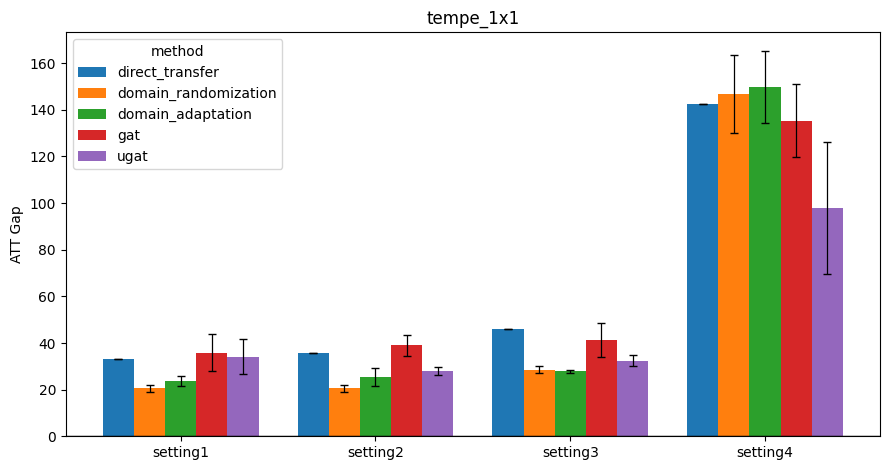

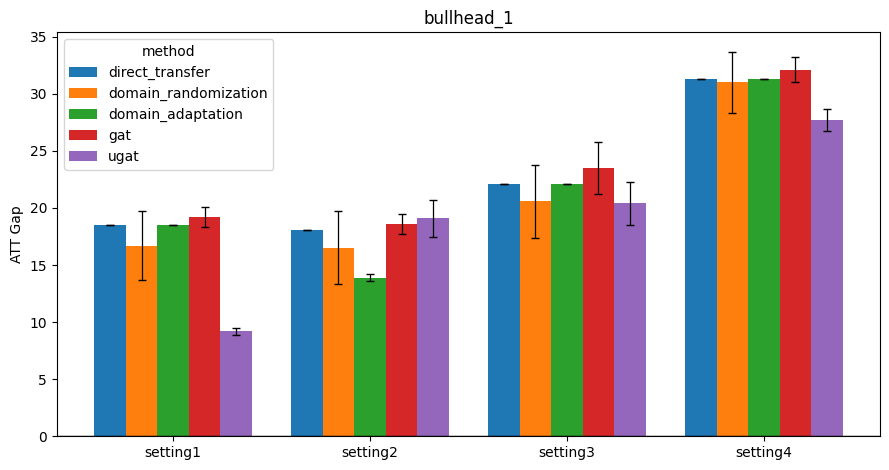

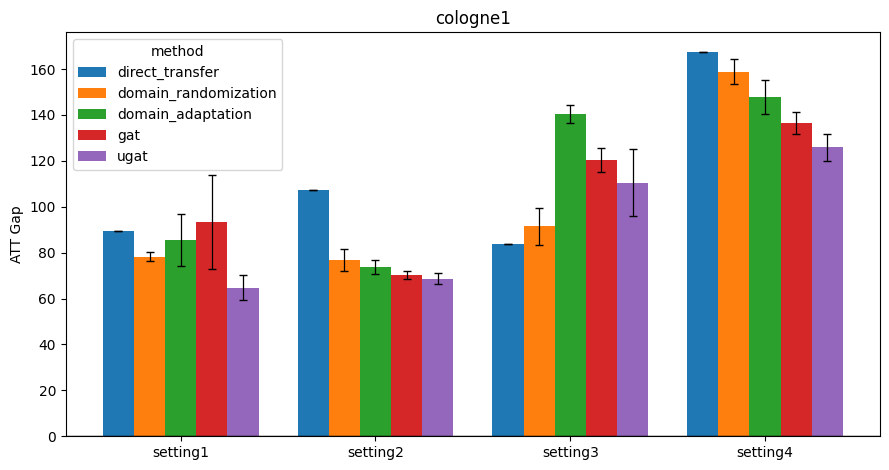

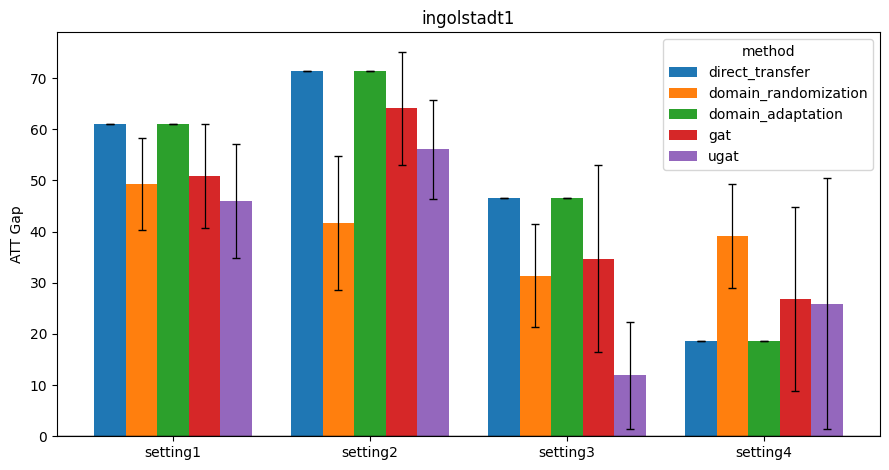

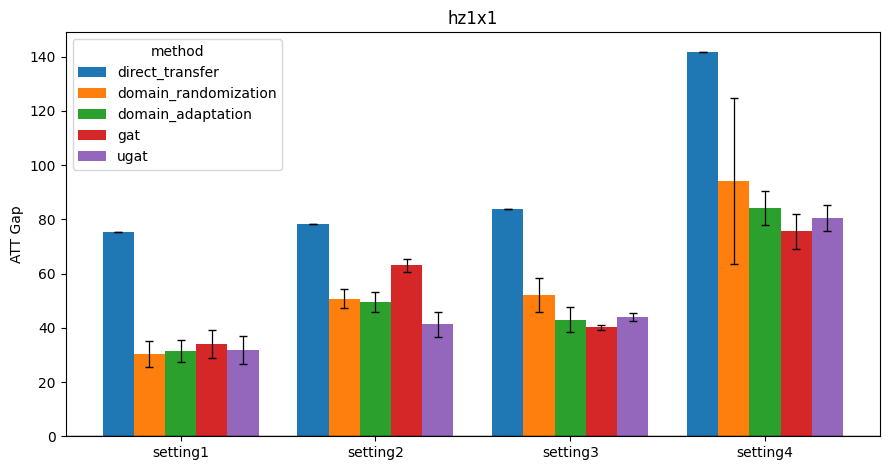

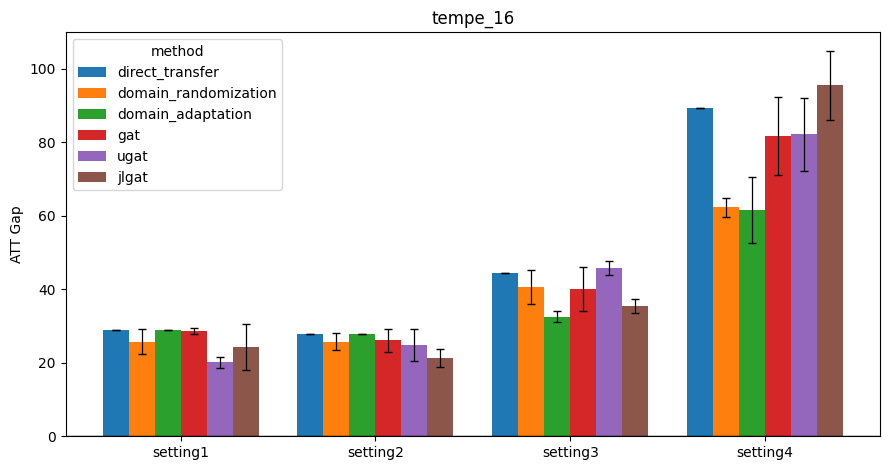

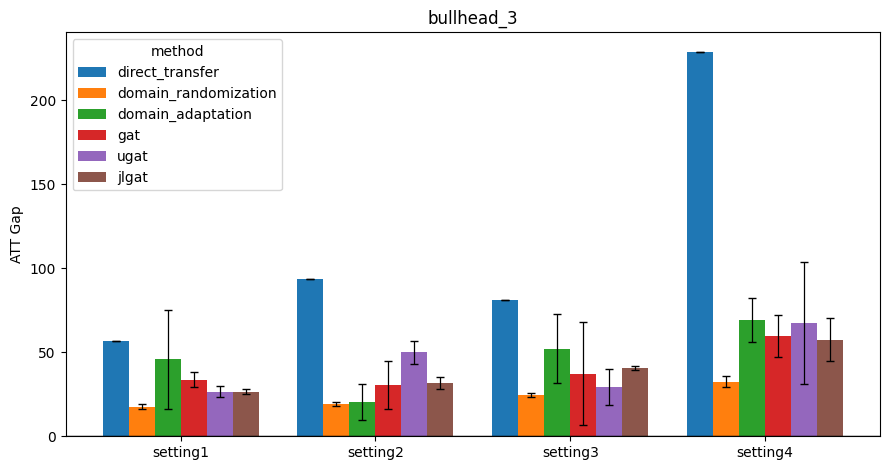

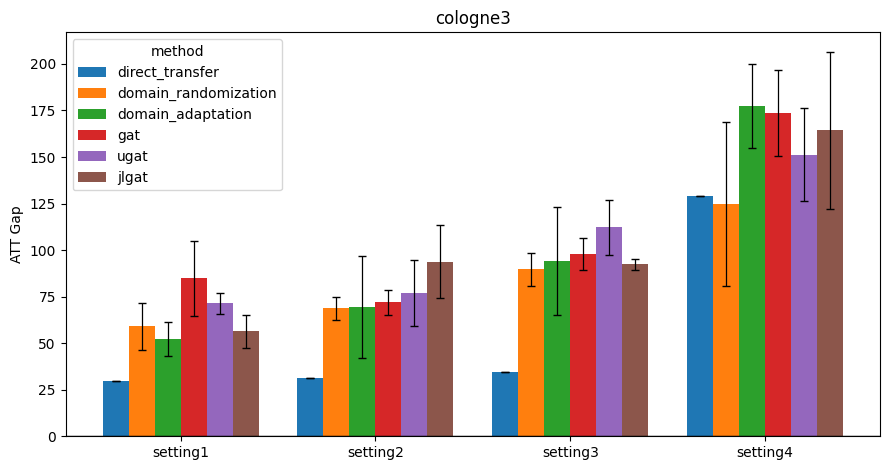

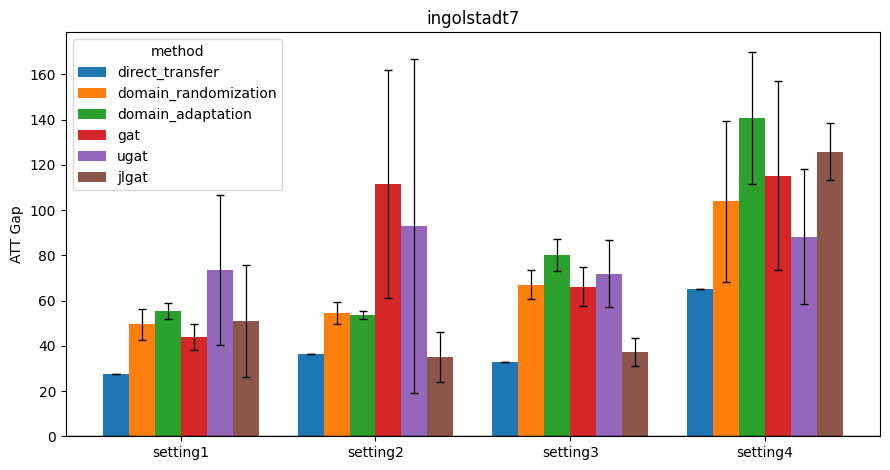

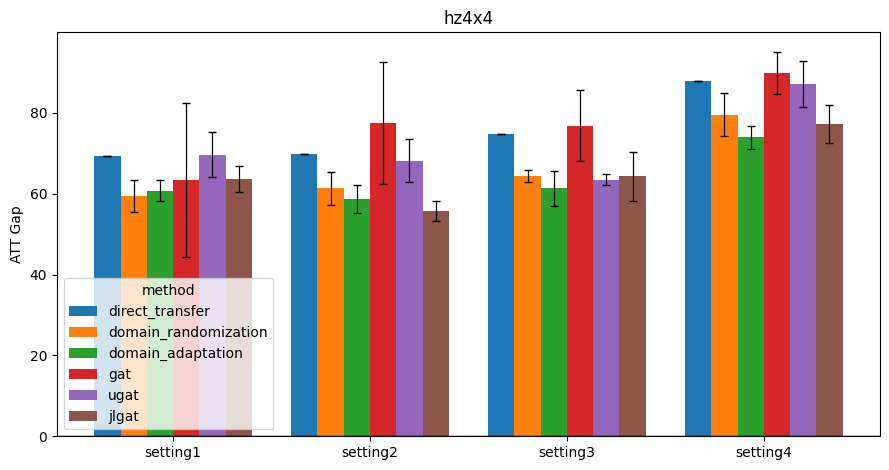

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for network in NETWORK_ORDER:
    plot_df = comparison_df[comparison_df["network"] == network].copy()
    if plot_df.empty:
        continue

    pivot_df = (
        plot_df.pivot(index="setting", columns="method", values="gap_vs_cityflow")
        .reindex(SETTING_ORDER)
    )
    error_df = (
        plot_df.pivot(index="setting", columns="method", values="travel_time_std")
        .reindex(SETTING_ORDER)
    )
    available_methods = [method for method in METHOD_ORDER if method in pivot_df.columns and pivot_df[method].notna().any()]
    if not available_methods:
        continue

    x = np.arange(len(SETTING_ORDER))
    width = 0.8 / len(available_methods)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    for idx, method in enumerate(available_methods):
        offsets = x - 0.4 + width / 2 + idx * width
        values = pd.to_numeric(pivot_df[method], errors="coerce").to_numpy(dtype=float)
        errors = (
            pd.to_numeric(error_df[method], errors="coerce").to_numpy(dtype=float)
            if method in error_df.columns
            else np.full(len(values), np.nan)
        )
        mask = ~np.isnan(values)
        yerr = np.where(np.isnan(errors[mask]), 0, errors[mask])
        ax.bar(
            offsets[mask],
            values[mask],
            width=width,
            yerr=yerr,
            capsize=3,
            ecolor="black",
            error_kw={"linewidth": 0.9},
            label=method,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(SETTING_ORDER)
    ax.set_ylabel("ATT Gap")
    ax.set_title(network)
    ax.legend(title="method")
    fig.tight_layout()
    plt.show()


In [8]:
# from pathlib import Path

# GAP_BAR_CHART_DIR = Path("figures/transition_gap_bar_chart")
# GAP_BAR_CHART_DIR.mkdir(parents=True, exist_ok=True)

# saved_gap_chart_paths = []
# for network in NETWORK_ORDER:
#     plot_df = comparison_df[comparison_df["network"] == network].copy()
#     if plot_df.empty:
#         continue

#     pivot_df = (
#         plot_df.pivot(index="setting", columns="method", values="gap_vs_cityflow")
#         .reindex(SETTING_ORDER)
#     )
#     error_df = (
#         plot_df.pivot(index="setting", columns="method", values="travel_time_std")
#         .reindex(SETTING_ORDER)
#     )
#     available_methods = [method for method in METHOD_ORDER if method in pivot_df.columns and pivot_df[method].notna().any()]
#     if not available_methods:
#         continue

#     x = np.arange(len(SETTING_ORDER))
#     width = 0.8 / len(available_methods)

#     fig, ax = plt.subplots(figsize=(9, 4.8))
#     for idx, method in enumerate(available_methods):
#         offsets = x - 0.4 + width / 2 + idx * width
#         values = pd.to_numeric(pivot_df[method], errors="coerce").to_numpy(dtype=float)
#         errors = (
#             pd.to_numeric(error_df[method], errors="coerce").to_numpy(dtype=float)
#             if method in error_df.columns
#             else np.full(len(values), np.nan)
#         )
#         mask = ~np.isnan(values)
#         yerr = np.where(np.isnan(errors[mask]), 0, errors[mask])
#         ax.bar(
#             offsets[mask],
#             values[mask],
#             width=width,
#             yerr=yerr,
#             capsize=3,
#             ecolor="black",
#             error_kw={"linewidth": 0.9},
#             label=method,
#         )

#     ax.axhline(0, color="black", linewidth=1)
#     ax.set_xticks(x)
#     ax.set_xticklabels(SETTING_ORDER)
#     ax.set_ylabel("ATT Gap")
#     ax.set_title(network)
#     ax.legend(title="method")
#     fig.tight_layout()

#     save_path = GAP_BAR_CHART_DIR / f"{network}_gap_bar_chart.png"
#     fig.savefig(save_path, dpi=300, bbox_inches="tight")
#     plt.close(fig)
#     saved_gap_chart_paths.append(save_path)

# saved_gap_chart_paths


## Picked Metric Mean and Std

This table uses the same picked rows as the summary tables above. Learned methods are summarized from their top `TOP_REWARD_K` real/equivalent rows by reward; direct transfer is a single final-test row, so its standard deviations are left blank. Each metric cell is formatted as `mean ± std` when a standard deviation is available.


In [9]:
def selected_metric_rows_from_modes(log_path: Path, modes, top_k: int = TOP_REWARD_K):
    df = read_tabular_dtl(log_path)
    mode_df = df[df["mode"].isin(modes)].copy()
    mode_df = mode_df[mode_df["travel_time"].notna() & mode_df["reward"].notna()]
    if mode_df.empty:
        return mode_df
    return mode_df.sort_values("reward", ascending=False).head(top_k).copy()


def selected_metric_rows_for_method(network: str, setting: str, method: str):
    row_df = comparison_df[
        (comparison_df["network"] == network)
        & (comparison_df["setting"] == setting)
        & (comparison_df["method"] == method)
    ]
    if row_df.empty or pd.isna(row_df.iloc[-1]["log_file"]):
        return pd.DataFrame(), None

    log_file = row_df.iloc[-1]["log_file"]
    if method == "direct_transfer":
        candidate_dirs = [LOG_ROOT / network / "sumo_direct_transfer" / setting]
        modes = ["FINAL_TEST"]
        use_top_reward = False
    elif method == "domain_randomization":
        candidate_dirs = [
            LOG_ROOT / network / "domain_randomization_eval" / setting,
            LOG_ROOT / network / "domain_randomization" / setting,
        ]
        modes = ["TEST_REAL", "TRAIN_REAL"]
        use_top_reward = True
    elif method == "domain_adaptation":
        candidate_dirs = [LOG_ROOT / network / "domain_adaptation" / setting]
        modes = ["REAL_EVAL", "REAL_EVAL_FINAL"]
        use_top_reward = True
    elif method in ["gat", "ugat", "jlgat"]:
        candidate_dirs = [LOG_ROOT / network / method / setting]
        modes = ["Real rollout"]
        use_top_reward = True
    else:
        return pd.DataFrame(), None

    log_path = next((candidate_dir / log_file for candidate_dir in candidate_dirs if (candidate_dir / log_file).exists()), None)
    if log_path is None:
        return pd.DataFrame(), None

    if use_top_reward:
        selected_df = selected_metric_rows_from_modes(log_path, modes)
    else:
        df = read_tabular_dtl(log_path)
        selected_df = df[df["mode"].isin(modes)].tail(1).copy()

    return selected_df, log_path


def format_mean_std(mean_value, std_value):
    if pd.isna(mean_value):
        return pd.NA
    if pd.isna(std_value):
        return f"{mean_value:.1f}"
    return f"{mean_value:.1f} ± {std_value:.1f}"


picked_metric_rows = []
for network in NETWORK_ORDER:
    for setting in SETTING_ORDER:
        for method in METHOD_ORDER:
            selected_df, log_path = selected_metric_rows_for_method(network, setting, method)
            if selected_df.empty:
                continue

            summary_row = {
                "network": network,
                "setting": setting,
                "method": method,
                "selection_count": int(len(selected_df)),
                "selected_episodes": ", ".join(str(int(episode)) for episode in selected_df["episode"].dropna()),
                "log_file": log_path.name,
            }
            for metric in METRIC_COLUMNS:
                values = selected_df[metric].dropna()
                summary_row[f"{metric}_mean"] = float(values.mean()) if not values.empty else pd.NA
                summary_row[f"{metric}_std"] = float(values.std(ddof=1)) if len(values) > 1 else pd.NA
            picked_metric_rows.append(summary_row)

picked_metric_summary_df = pd.DataFrame(picked_metric_rows)

picked_metric_display_df = picked_metric_summary_df[["network", "setting", "method"]].copy()
for metric in METRIC_COLUMNS:
    picked_metric_display_df[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            picked_metric_summary_df[f"{metric}_mean"],
            picked_metric_summary_df[f"{metric}_std"],
        )
    ]

picked_metric_display_df = picked_metric_display_df[["network", "setting", "method", *METRIC_COLUMNS]]
display(picked_metric_display_df)


,network,setting,method,travel_time,aux,reward,queue,delay,throughput
0,tempe_1x1,setting1,direct_transfer,176.2,100.0,-64.4,24.0,0.5,1751.0
1,tempe_1x1,setting1,domain_randomization,163.6 ± 1.4,100.0 ± 0.0,-48.5 ± 0.7,8.1 ± 0.7,0.4 ± 0.0,1828.8 ± 1.8
2,tempe_1x1,setting1,domain_adaptation,166.7 ± 2.2,0.0 ± 0.0,-50.3 ± 1.1,10.1 ± 1.1,0.5 ± 0.0,1827.0 ± 2.0
3,tempe_1x1,setting1,gat,178.9 ± 7.9,100.0 ± 0.0,-58.6 ± 5.3,17.9 ± 5.3,0.5 ± 0.1,1805.2 ± 31.0
4,tempe_1x1,setting1,ugat,177.1 ± 7.6,100.0 ± 0.0,-56.1 ± 4.4,15.5 ± 4.3,0.5 ± 0.0,1820.4 ± 6.5
...,...,...,...,...,...,...,...,...,...
215,hz4x4,setting4,domain_randomization,429.0 ± 5.4,100.0 ± 0.0,-82.0 ± 0.4,5.6 ± 0.2,0.2 ± 0.0,2464.0 ± 5.7
216,hz4x4,setting4,domain_adaptation,423.4 ± 2.8,0.0 ± 0.0,-83.2 ± 1.1,5.5 ± 0.2,0.2 ± 0.0,2463.8 ± 6.1
217,hz4x4,setting4,gat,439.3 ± 5.3,100.0 ± 0.0,-94.8 ± 2.3,8.9 ± 3.3,0.2 ± 0.0,2352.6 ± 101.3
218,hz4x4,setting4,ugat,436.6 ± 5.6,100.0 ± 0.0,-83.5 ± 0.9,6.3 ± 0.5,0.2 ± 0.0,2453.2 ± 16.8


In [10]:
picked_metric_display_df.to_csv("transition_table.csv", index=False)

In [11]:
picked_metric_display_df

,network,setting,method,travel_time,aux,reward,queue,delay,throughput
0,tempe_1x1,setting1,direct_transfer,176.2,100.0,-64.4,24.0,0.5,1751.0
1,tempe_1x1,setting1,domain_randomization,163.6 ± 1.4,100.0 ± 0.0,-48.5 ± 0.7,8.1 ± 0.7,0.4 ± 0.0,1828.8 ± 1.8
2,tempe_1x1,setting1,domain_adaptation,166.7 ± 2.2,0.0 ± 0.0,-50.3 ± 1.1,10.1 ± 1.1,0.5 ± 0.0,1827.0 ± 2.0
3,tempe_1x1,setting1,gat,178.9 ± 7.9,100.0 ± 0.0,-58.6 ± 5.3,17.9 ± 5.3,0.5 ± 0.1,1805.2 ± 31.0
4,tempe_1x1,setting1,ugat,177.1 ± 7.6,100.0 ± 0.0,-56.1 ± 4.4,15.5 ± 4.3,0.5 ± 0.0,1820.4 ± 6.5
...,...,...,...,...,...,...,...,...,...
215,hz4x4,setting4,domain_randomization,429.0 ± 5.4,100.0 ± 0.0,-82.0 ± 0.4,5.6 ± 0.2,0.2 ± 0.0,2464.0 ± 5.7
216,hz4x4,setting4,domain_adaptation,423.4 ± 2.8,0.0 ± 0.0,-83.2 ± 1.1,5.5 ± 0.2,0.2 ± 0.0,2463.8 ± 6.1
217,hz4x4,setting4,gat,439.3 ± 5.3,100.0 ± 0.0,-94.8 ± 2.3,8.9 ± 3.3,0.2 ± 0.0,2352.6 ± 101.3
218,hz4x4,setting4,ugat,436.6 ± 5.6,100.0 ± 0.0,-83.5 ± 0.9,6.3 ± 0.5,0.2 ± 0.0,2453.2 ± 16.8


## Real-Eval Metric Traces

To keep the plots readable, each figure shows one network/setting pair. Metrics are split into small multiples, and each line is one method with real/equivalent evaluation rows in its selected DTL log. Adjust `REAL_EVAL_TRACE_NETWORKS`, `REAL_EVAL_TRACE_SETTINGS`, or `REAL_EVAL_TRACE_METHODS` to narrow the output.


,network,setting,method,log_file,episodes,first_episode,last_episode
0,bullhead_1,setting1,domain_adaptation,2026_04_25-01_27_42_DTL.log,101,0,100
1,bullhead_1,setting1,gat,2026_04_23-12_32_10_DTL.log,100,0,99
2,bullhead_1,setting1,ugat,2026_04_23-13_36_44_DTL.log,100,0,99
3,bullhead_1,setting2,domain_adaptation,2026_04_25-01_38_15_DTL.log,101,0,100
4,bullhead_1,setting2,gat,2026_04_23-12_48_33_DTL.log,100,0,99
...,...,...,...,...,...,...,...
135,tempe_1x1,setting3,gat,2026_04_23-13_24_13_DTL.log,100,0,99
136,tempe_1x1,setting3,ugat,2026_04_23-15_04_19_DTL.log,100,0,99
137,tempe_1x1,setting4,domain_adaptation,2026_04_25-01_01_04_DTL.log,101,0,100
138,tempe_1x1,setting4,gat,2026_04_23-13_52_03_DTL.log,100,0,99


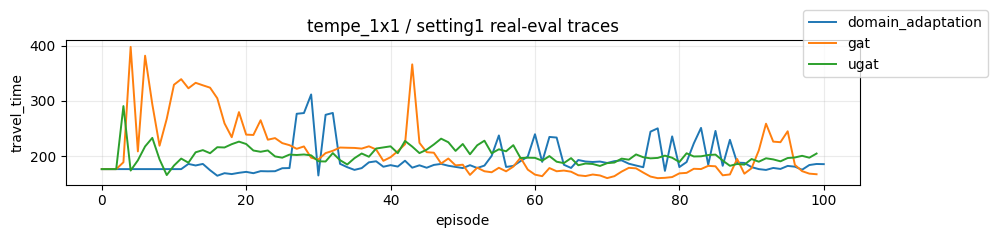

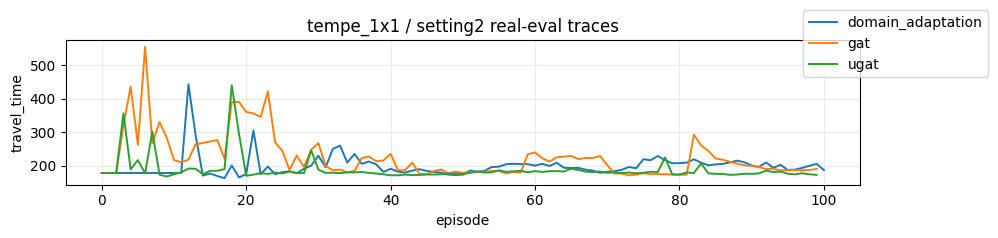

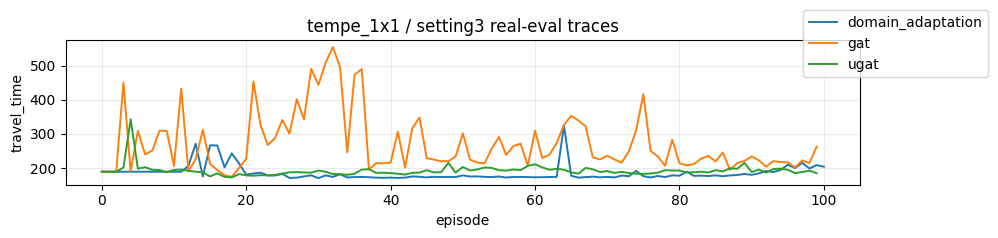

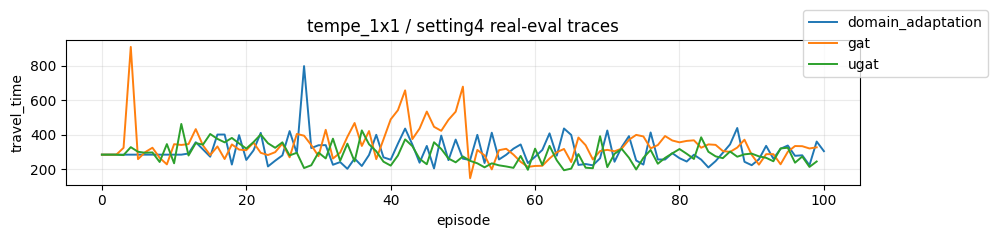

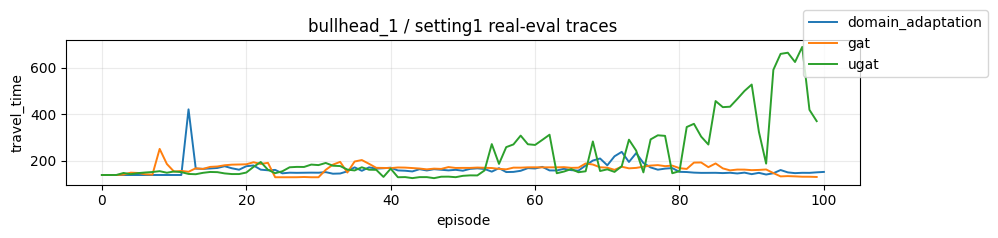

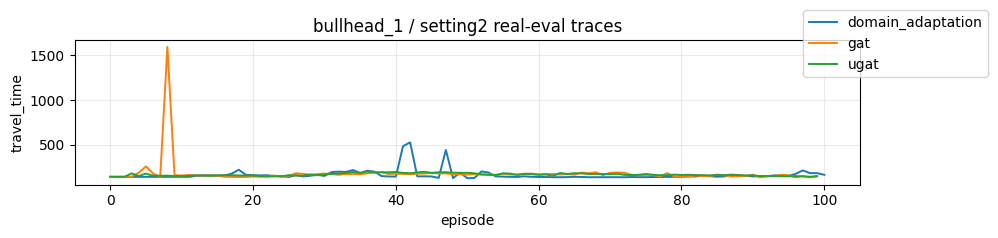

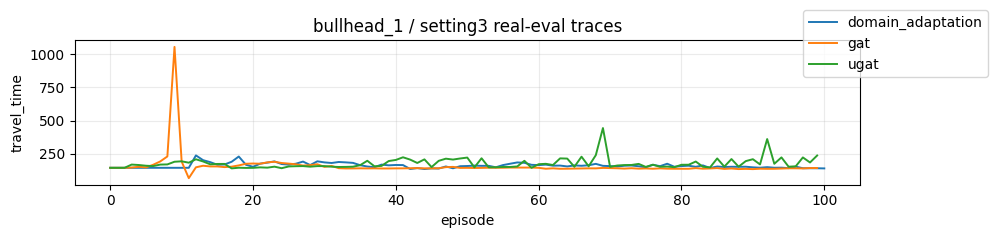

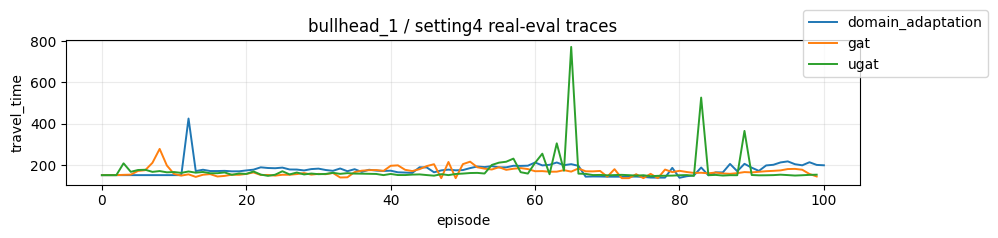

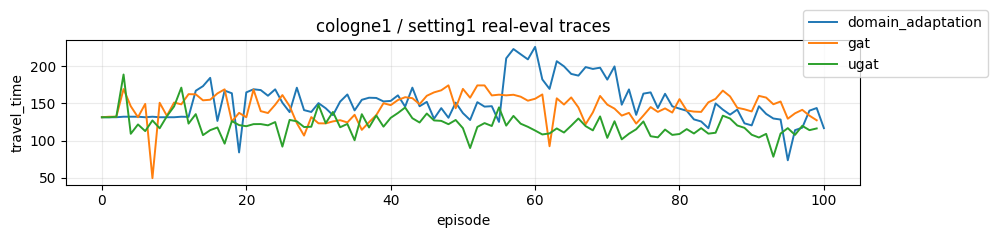

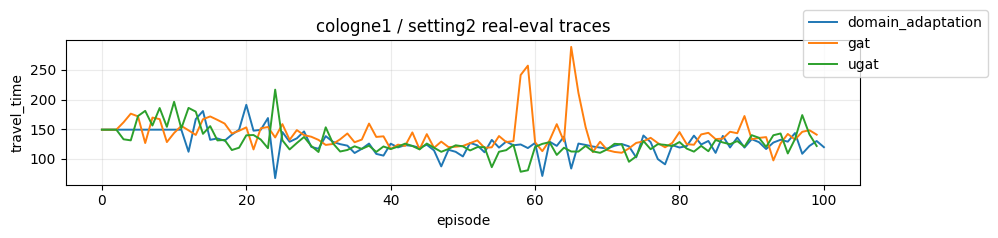

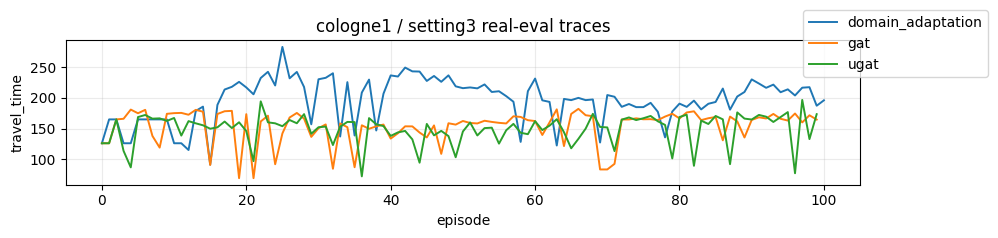

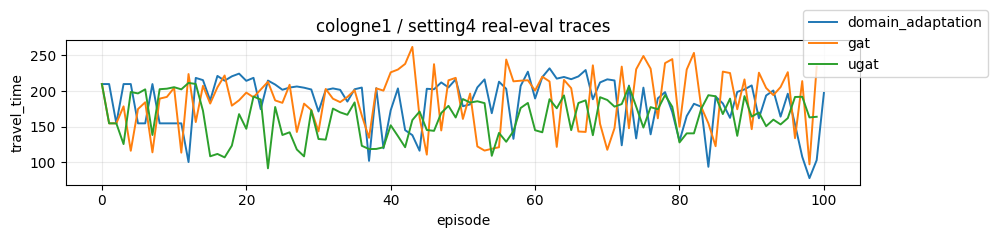

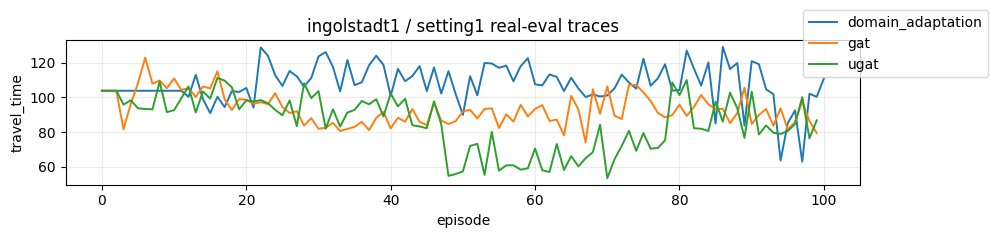

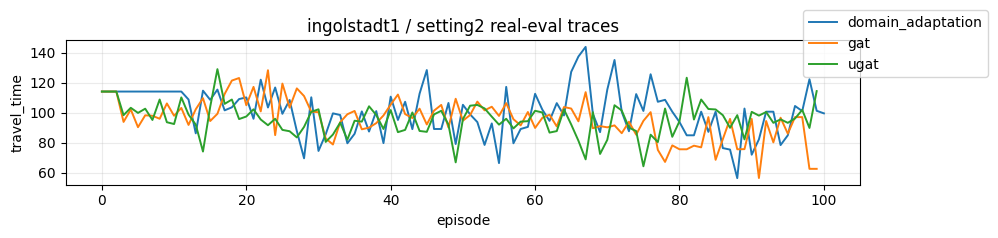

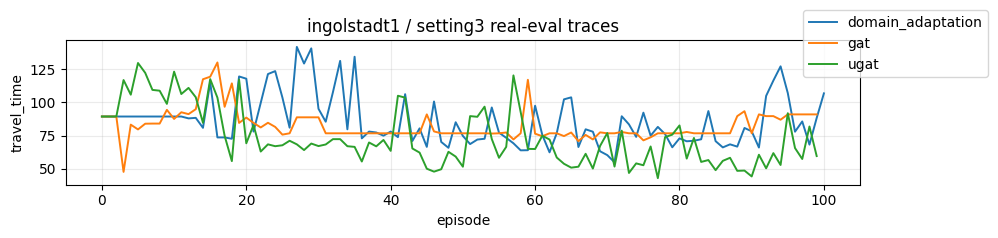

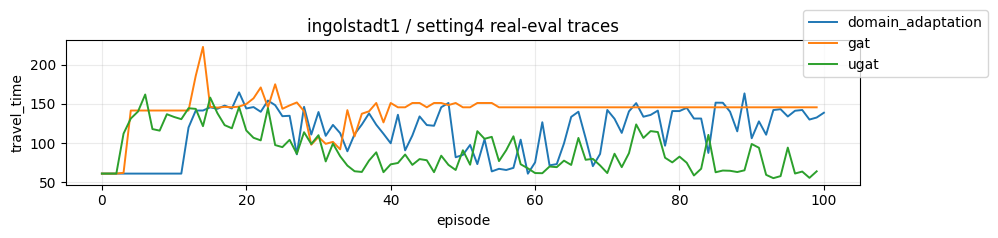

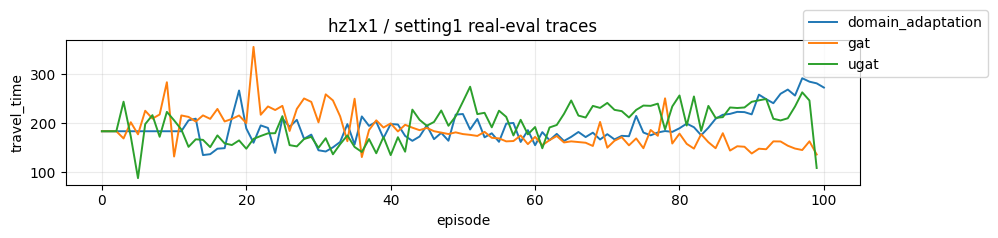

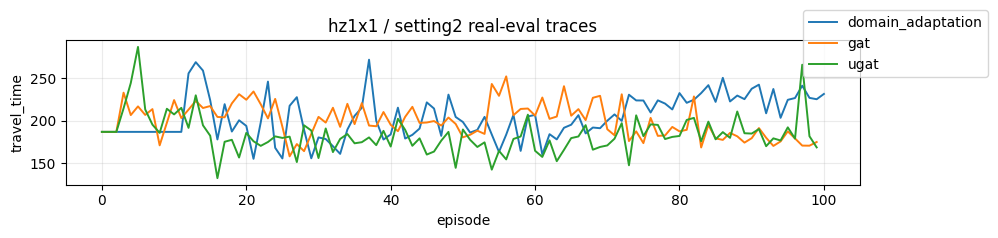

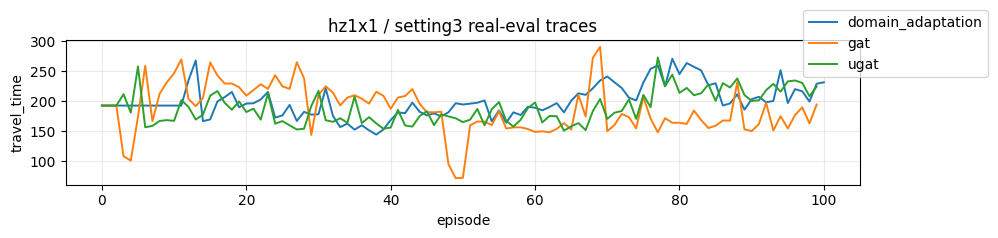

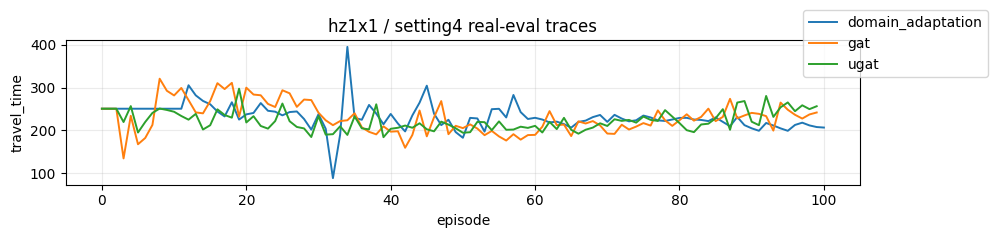

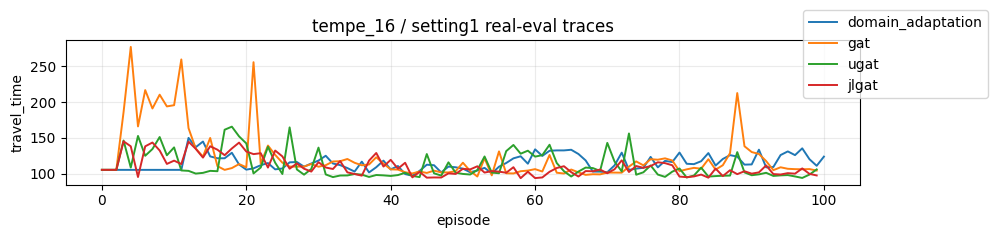

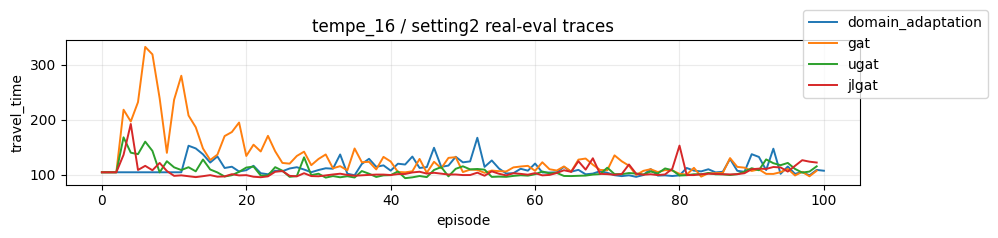

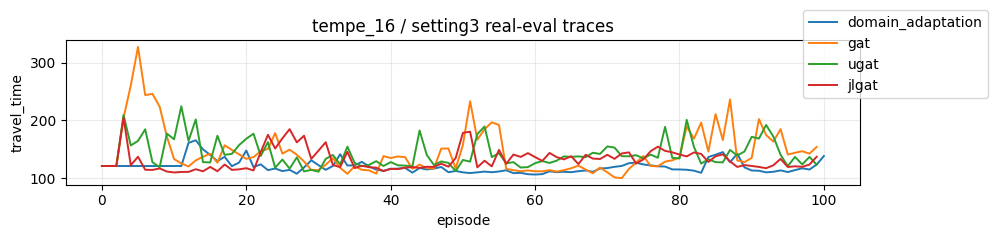

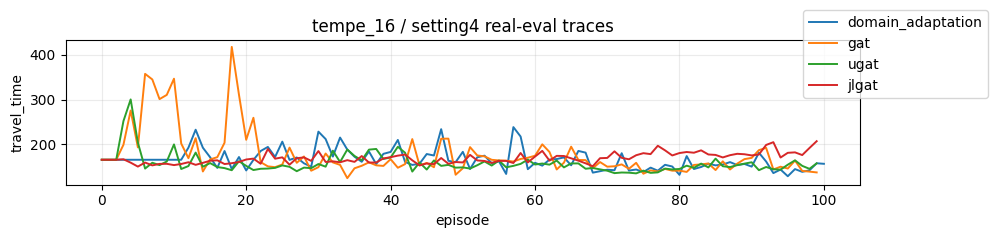

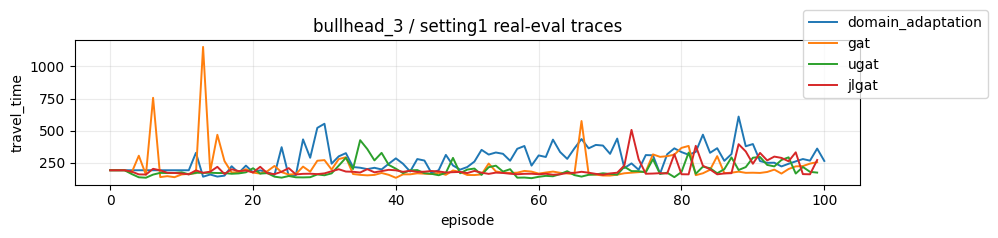

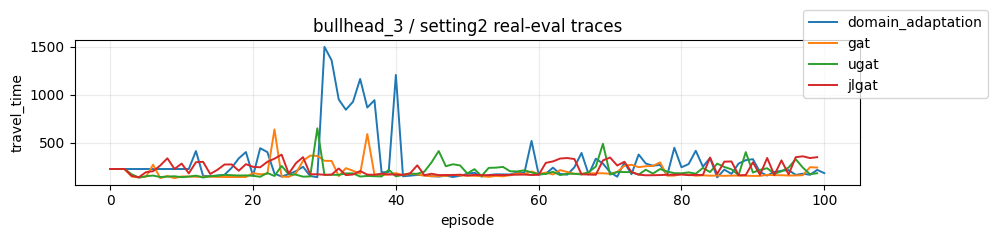

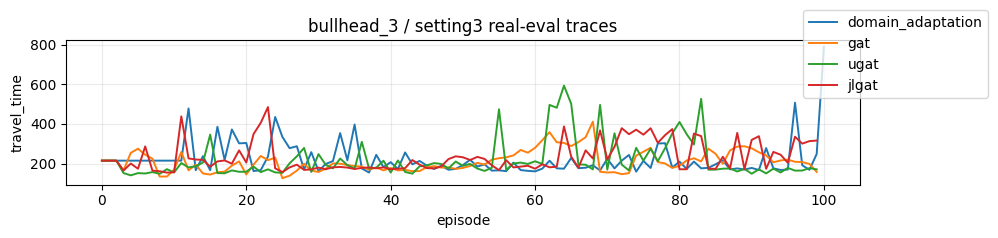

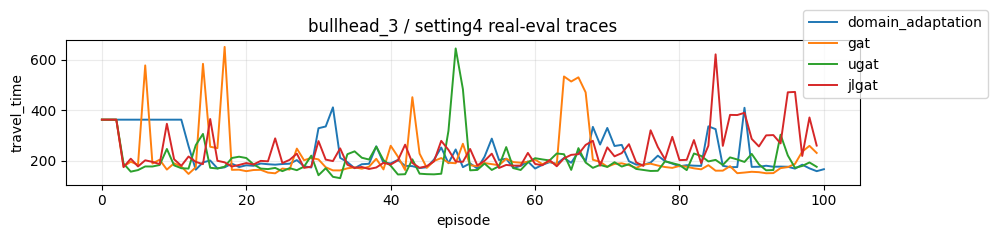

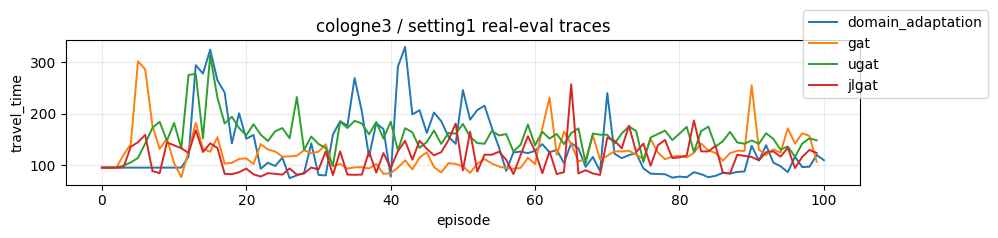

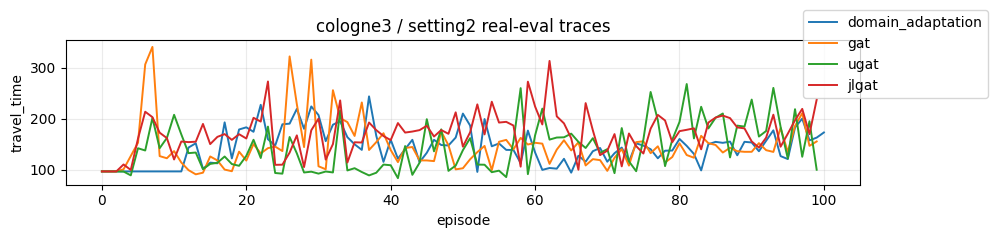

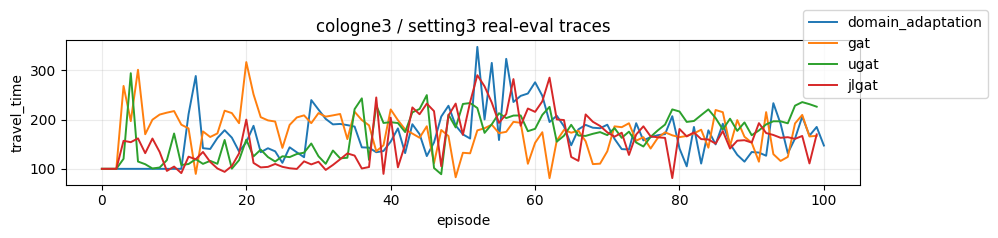

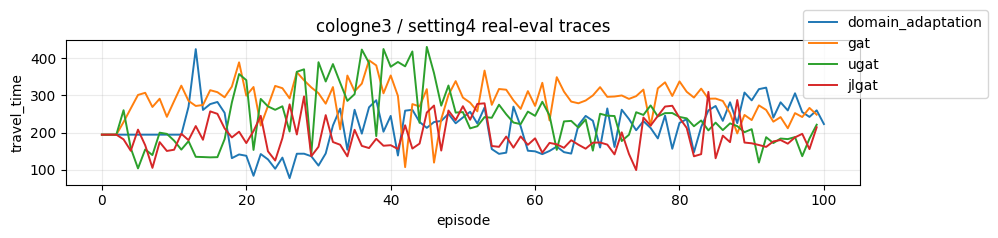

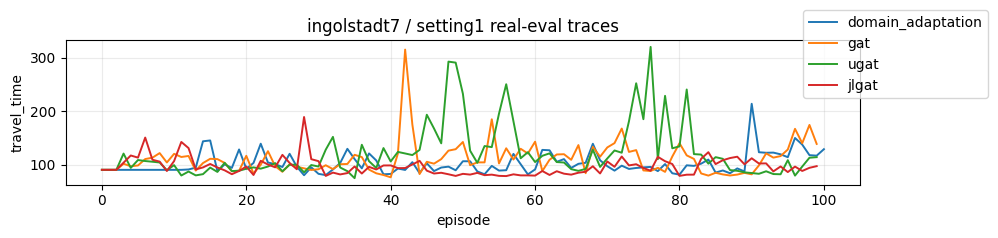

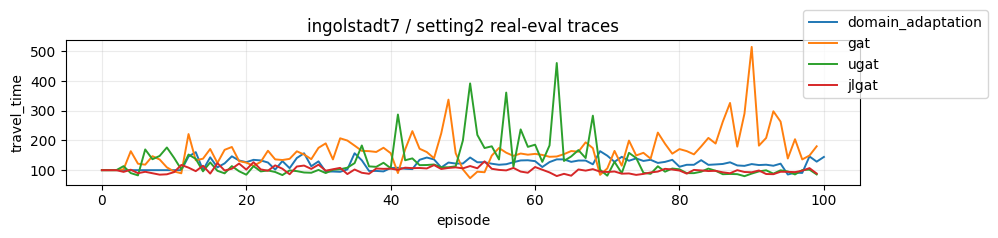

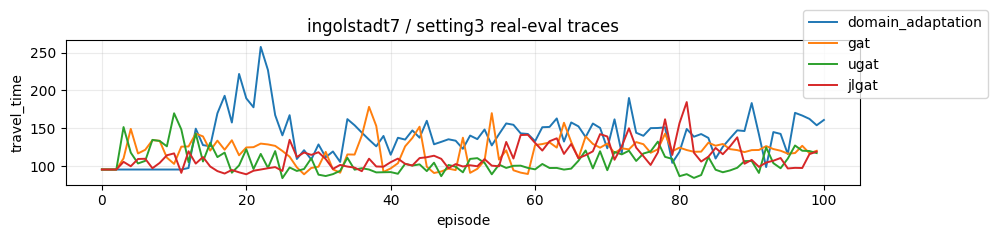

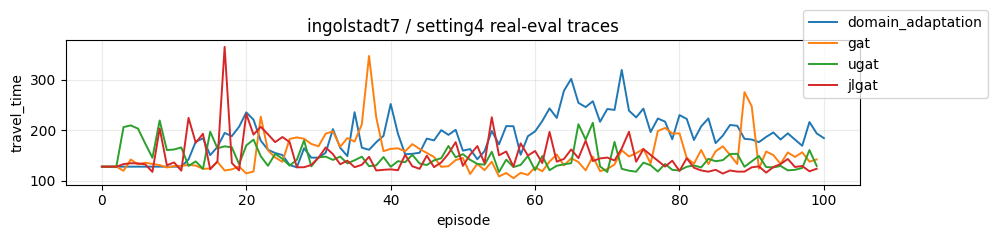

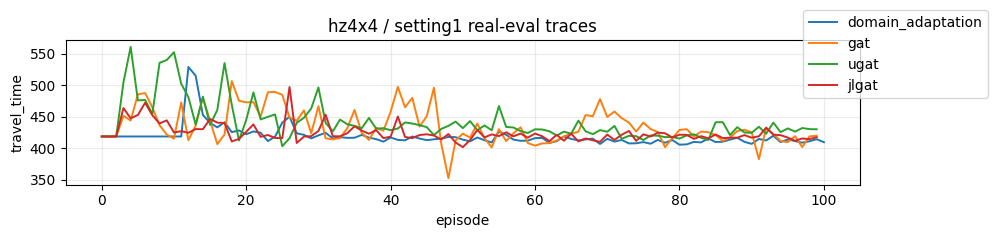

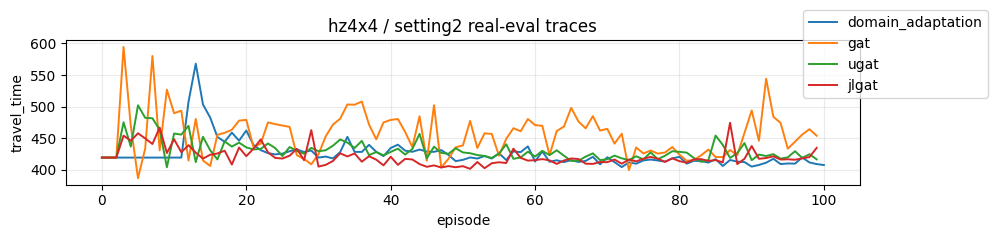

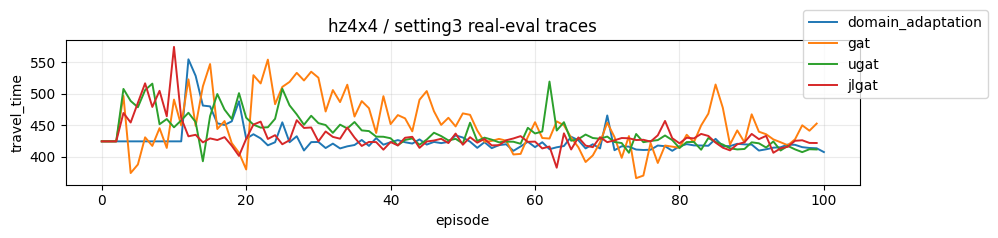

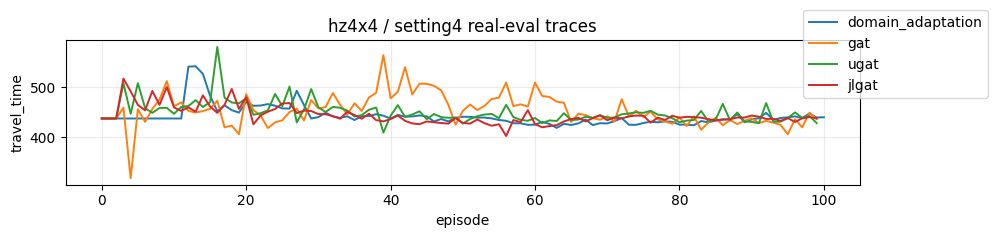

In [14]:
REAL_EVAL_TRACE_NETWORKS = ["tempe_1x1", "bullhead_1", "cologne1", "ingolstadt1", "hz1x1", "tempe_16", "bullhead_3", "cologne3", "ingolstadt7", "hz4x4"]
REAL_EVAL_TRACE_SETTINGS = ["setting1", "setting2", "setting3", "setting4"]
REAL_EVAL_TRACE_METHODS = [ "domain_adaptation", "gat", "ugat", "jlgat"]
# REAL_EVAL_TRACE_METRICS = ["travel_time", "reward", "queue", "delay", "throughput"]
REAL_EVAL_TRACE_METRICS = ["travel_time"]

REAL_EVAL_MODES_BY_METHOD = {
    "domain_randomization": ["TEST_REAL", "TRAIN_REAL"],
    "domain_adaptation": ["REAL_EVAL", "REAL_EVAL_FINAL"],
    "gat": ["Real rollout"],
    "ugat": ["Real rollout"],
    "jlgat": ["Real rollout"],
}


def metric_trace_for_method(network: str, setting: str, method: str):
    row_df = comparison_df[
        (comparison_df["network"] == network)
        & (comparison_df["setting"] == setting)
        & (comparison_df["method"] == method)
    ]
    if row_df.empty or pd.isna(row_df.iloc[-1]["log_file"]):
        return pd.DataFrame()

    log_file = row_df.iloc[-1]["log_file"]
    if method == "domain_randomization":
        candidate_dirs = [
            LOG_ROOT / network / "domain_randomization_eval" / setting,
            LOG_ROOT / network / "domain_randomization" / setting,
        ]
    elif method == "domain_adaptation":
        candidate_dirs = [LOG_ROOT / network / "domain_adaptation" / setting]
    elif method in ["gat", "ugat", "jlgat"]:
        candidate_dirs = [LOG_ROOT / network / method / setting]
    else:
        return pd.DataFrame()

    log_path = next((candidate_dir / log_file for candidate_dir in candidate_dirs if (candidate_dir / log_file).exists()), None)
    if log_path is None:
        return pd.DataFrame()

    text = log_path.read_text().strip()
    if not text:
        return pd.DataFrame()

    if "\t" in text.splitlines()[0]:
        trace_df = read_tabular_dtl(log_path)
        trace_df = trace_df[trace_df["mode"].isin(REAL_EVAL_MODES_BY_METHOD[method])].copy()
    else:
        rows = []
        for line in text.splitlines():
            match = TEXT_REAL_ROLLOUT_RE.match(line.strip())
            if match:
                rows.append({
                    "episode": int(match.group("episode")),
                    "travel_time": float(match.group("travel_time")),
                })
        trace_df = pd.DataFrame(rows)

    if trace_df.empty:
        return trace_df

    trace_df["network"] = network
    trace_df["setting"] = setting
    trace_df["method"] = method
    trace_df["log_file"] = log_path.name
    return trace_df.sort_values("episode")


real_eval_trace_rows = []
for network in REAL_EVAL_TRACE_NETWORKS:
    for setting in REAL_EVAL_TRACE_SETTINGS:
        for method in REAL_EVAL_TRACE_METHODS:
            trace_df = metric_trace_for_method(network, setting, method)
            if not trace_df.empty:
                real_eval_trace_rows.append(trace_df)

real_eval_trace_df = (
    pd.concat(real_eval_trace_rows, ignore_index=True)
    if real_eval_trace_rows
    else pd.DataFrame(columns=["network", "setting", "method", "episode", *METRIC_COLUMNS, "log_file"])
)

trace_inventory_df = (
    real_eval_trace_df.groupby(["network", "setting", "method", "log_file"], dropna=False)
    .agg(episodes=("episode", "count"), first_episode=("episode", "min"), last_episode=("episode", "max"))
    .reset_index()
)
display(trace_inventory_df)

for network in REAL_EVAL_TRACE_NETWORKS:
    for setting in REAL_EVAL_TRACE_SETTINGS:
        plot_df = real_eval_trace_df[(real_eval_trace_df["network"] == network) & (real_eval_trace_df["setting"] == setting)]
        if plot_df.empty:
            continue

        metrics_to_plot = [metric for metric in REAL_EVAL_TRACE_METRICS if metric in plot_df.columns and plot_df[metric].notna().any()]
        if not metrics_to_plot:
            continue

        fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 2.4 * len(metrics_to_plot)), sharex=True)
        axes = np.atleast_1d(axes)
        for ax, metric in zip(axes, metrics_to_plot):
            for method in REAL_EVAL_TRACE_METHODS:
                method_df = plot_df[plot_df["method"] == method]
                if method_df.empty or method_df[metric].isna().all():
                    continue
                ax.plot(method_df["episode"], method_df[metric], linewidth=1.4, label=method)
            ax.set_ylabel(metric)
            ax.grid(True, alpha=0.25)

        axes[-1].set_xlabel("episode")
        axes[0].set_title(f"{network} / {setting} real-eval traces")
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.0))
        fig.tight_layout(rect=(0, 0, 0.88, 1))
        plt.show()


## Bullhead 3 Setting 2 Bar Chart

This separate bar-chart cell compares the selected `bullhead_3` / `setting2` method results using the same picked rows shown in the tables above.
